<div align="center">

<h1> <b> SEMI-EMPIRICAL MASS FORMULA AND LOCAL FIT FOR A = 131 </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Ross Miranda <br>
Cristian Vergara</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---

## 1. Introducción

En este trabajo se emplean datos experimentales de energías de enlace nuclear para comparar la energía de enlace por nucleón, $\mathrm{BE}/A$, con la predicción de la **fórmula semiempírica de masas** (o modelo de gota líquida), y para realizar un ajuste parabólico local de la masa nuclear en la cadena isobárica $A = 131$.

La masa nuclear se describe localmente, en función del número atómico $Z$, mediante

$$
M(Z) = \alpha + \beta\,Z + \gamma\,Z^2,
$$

lo que permite estimar los valores de $Q_\beta$ (energía liberada en la desintegración $\beta^-$) y compararlos con los valores obtenidos directamente de las masas experimentales. Los cálculos numéricos se realizan con NumPy (Harris et al., 2020) y pandas, y las figuras se generan con Matplotlib (Hunter, 2007).

## 2. Lectura de Datos y Visualización Inicial

Los datos experimentales se encuentran en el archivo `mybinding.dat`, con cuatro columnas:

- $Z$: número atómico (protones).
- $A$: número de masa.
- $\mathrm{BE}_{\exp}$: energía de enlace experimental, en MeV.
- $N = A - Z$: número de neutrones.

El formato de estas columnas es consistente con el de las evaluaciones de masas atómicas de uso estándar en física nuclear, como AME2020 (Wang et al., 2021); no obstante, no fue posible confirmar con certeza la edición exacta de la que proviene este archivo en particular.

A continuación se grafica la energía de enlace por nucleón, $\mathrm{BE}/A$, en función de $A$, $N$ y $Z$, para obtener una visión global de los datos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ruta del archivo de datos experimentales de energía de enlace nuclear.
# El archivo contiene, por columnas: Z, A, BE_exp (MeV) y N.
RUTA_DATOS = "mybinding.dat"

datos_enlace = np.loadtxt(RUTA_DATOS)

Z = datos_enlace[:, 0]
A = datos_enlace[:, 1]
BE = datos_enlace[:, 2]
N = datos_enlace[:, 3]

print("Primeros 5 registros leidos:")
for i in range(5):
    print(f"Z={Z[i]:.0f}, A={A[i]:.0f}, BE={BE[i]:.4f} MeV, N={N[i]:.0f}")

Primeros 5 registros leidos:
Z=1, A=2, BE=2.2246 MeV, N=1
Z=1, A=3, BE=8.4818 MeV, N=2
Z=1, A=4, BE=6.8818 MeV, N=3
Z=1, A=5, BE=6.6818 MeV, N=4
Z=1, A=6, BE=5.7698 MeV, N=5


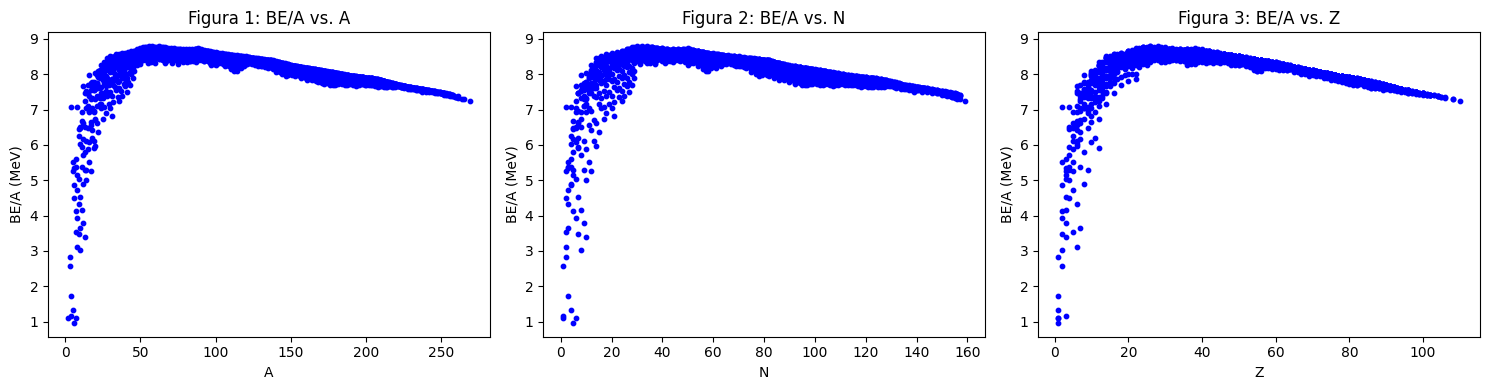

In [2]:
# Vision global de BE/A en funcion de A, N y Z.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(A, BE / A, color="blue", s=10)
axes[0].set_xlabel("A")
axes[0].set_ylabel("BE/A (MeV)")
axes[0].set_title("Figura 1: BE/A vs. A")

axes[1].scatter(N, BE / A, color="blue", s=10)
axes[1].set_xlabel("N")
axes[1].set_ylabel("BE/A (MeV)")
axes[1].set_title("Figura 2: BE/A vs. N")

axes[2].scatter(Z, BE / A, color="blue", s=10)
axes[2].set_xlabel("Z")
axes[2].set_ylabel("BE/A (MeV)")
axes[2].set_title("Figura 3: BE/A vs. Z")

plt.tight_layout()
plt.show()

### Análisis de las Figuras 1, 2 y 3

Las tres gráficas muestran el comportamiento característico de la energía de enlace por nucleón. Al graficar $\mathrm{BE}/A$ contra $A$ (Fig. 1), se observa un incremento hasta un máximo cercano a $A \approx 60$, seguido de un descenso paulatino para núcleos más pesados. Las gráficas contra $N$ y contra $Z$ (Figs. 2 y 3) son equivalentes entre sí, pero permiten apreciar cómo varía $\mathrm{BE}/A$ con la proporción de neutrones y protones en el núcleo.

---

## 3. Modelo de Gota Líquida: Comparación Global

La fórmula semiempírica de masas, sin incluir el término de apareamiento $\delta$, se escribe como

$$
B(A,Z) = a_1 A - a_2 A^{2/3} - a_3 \frac{Z^2}{A^{1/3}} - a_4 \frac{(N-Z)^2}{A}.
$$

Los coeficientes empleados a continuación ($a_1 = 15.48$, $a_2 = 17.23$, $a_3 = 0.697$ y $a_4 = 22.6$ MeV) corresponden a valores típicos reportados para esta parametrización sin término de apareamiento (Krane, 1988). A continuación se compara la energía de enlace por nucleón experimental con la que predice el modelo, incluyendo cada término de forma acumulativa (volumen, +superficie, +Coulomb, +asimetría).

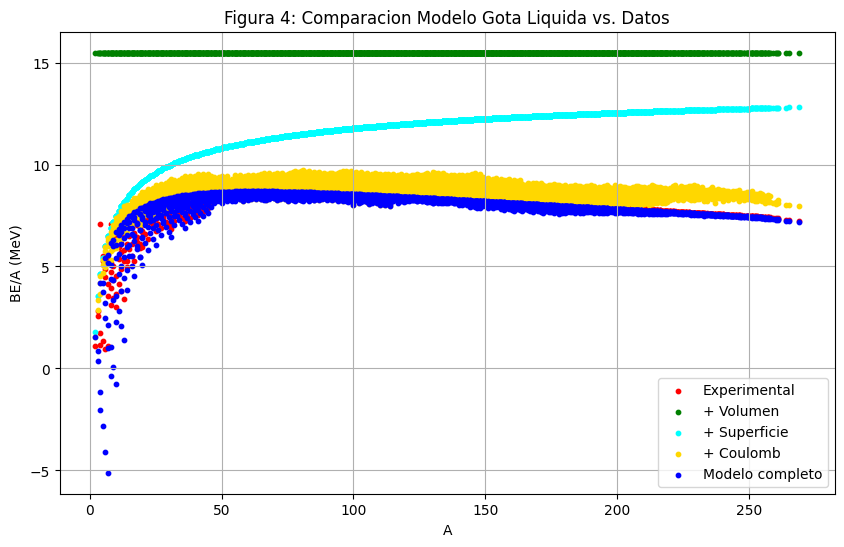

In [3]:
def BE_liquida(A, Z, N, alpha1=15.48, alpha2=17.23, alpha3=0.697, alpha4=22.6):
    """Energia de enlace total predicha por el modelo de gota liquida.

    Implementa la formula semiempirica de masas sin termino de apareamiento:
    B(A, Z) = a1*A - a2*A^(2/3) - a3*Z^2/A^(1/3) - a4*(N-Z)^2/A.

    Parametros
    ----------
    A, Z, N : array_like
        Numero de masa, numero atomico y numero de neutrones.
    alpha1..alpha4 : float
        Coeficientes de volumen, superficie, Coulomb y asimetria (MeV).
        Poner en cero el coeficiente de un termino lo excluye del calculo,
        lo que permite construir las curvas acumulativas de la Figura 4.

    Retorna
    -------
    ndarray
        Energia de enlace total predicha, en MeV.
    """
    return (alpha1 * A
            - alpha2 * A**(2 / 3)
            - alpha3 * Z**2 / A**(1 / 3)
            - alpha4 * (N - Z)**2 / A)


# Modelo completo y contribuciones acumulativas de cada termino.
BE_modelo_volumen = BE_liquida(A, Z, N, alpha2=0, alpha3=0, alpha4=0)
BE_modelo_sup = BE_liquida(A, Z, N, alpha3=0, alpha4=0)
BE_modelo_coulomb = BE_liquida(A, Z, N, alpha4=0)
BE_modelo = BE_liquida(A, Z, N)

plt.figure(figsize=(10, 6))
plt.scatter(A, BE / A, color="red", s=10, label="Experimental")
plt.scatter(A, BE_modelo_volumen / A, color="green", s=10, label="+ Volumen")
plt.scatter(A, BE_modelo_sup / A, color="cyan", s=10, label="+ Superficie")
plt.scatter(A, BE_modelo_coulomb / A, color="gold", s=10, label="+ Coulomb")
plt.scatter(A, BE_modelo / A, color="blue", s=10, label="Modelo completo")

plt.xlabel("A")
plt.ylabel("BE/A (MeV)")
plt.title("Figura 4: Comparacion Modelo Gota Liquida vs. Datos")
plt.legend()
plt.grid(True)
plt.show()

### Discusión de la Figura 4

La curva experimental (puntos rojos) exhibe el máximo de la energía de enlace por nucleón cerca de $A \approx 60$. El término de volumen (verde) es una aproximación aproximadamente constante, de unos 15 MeV/nucleón, que sobreestima la energía para núcleos ligeros y no reproduce la caída observada en núcleos pesados. Al añadir el término de superficie (cian) se corrige la disminución para núcleos pequeños y la leve bajada para núcleos pesados. La inclusión del término de Coulomb (amarillo) incorpora la repulsión entre protones, desplazando el máximo hacia valores de $A$ más cercanos a los datos. Finalmente, el modelo completo (azul), que agrega la corrección de asimetría $(N-Z)^2$, reproduce de manera cercana la forma de la curva experimental, aunque persisten diferencias atribuibles a efectos de apareamiento, deformaciones nucleares y otros fenómenos de estructura fina no incluidos en el modelo.

---

## 4. Ajuste Local de Masas para A = 131

Nos enfocamos ahora en los isóbaros con $A = 131$. La masa nuclear se aproxima como

$$
M(Z, A) \approx Z\,m_p + (A - Z)\,m_n - \mathrm{BE}_{\exp},
$$

con $m_p \approx 938.272$ MeV/$c^2$ y $m_n \approx 939.565$ MeV/$c^2$.

### 4.1. Cálculo de masas y filtrado para A = 131

In [4]:
# Constantes de masa del proton y del neutron, en MeV/c^2.
m_p = 938.2720813
m_n = 939.5654133


def masa_nuclear(Z, A, BE):
    """Masa nuclear aproximada, en MeV/c^2, a partir de la energia de enlace.

    Se calcula como la suma de las masas de los nucleones libres menos la
    energia de enlace: M(Z, A) = Z*m_p + (A-Z)*m_n - BE.
    """
    return Z * m_p + (A - Z) * m_n - BE


# Se reutilizan los datos ya leidos (Z, A, BE) para construir un DataFrame,
# lo que evita leer el archivo de datos una segunda vez.
df = pd.DataFrame({"Z": Z.astype(int), "A": A.astype(int), "BE_exp": BE})
df["mass"] = masa_nuclear(df["Z"], df["A"], df["BE_exp"])

# Filtrado de los isobaros con A = 131.
df_A131 = df[df["A"] == 131].copy().reset_index(drop=True)
print("Datos para A=131:")
print(df_A131)

Datos para A=131:
     Z    A     BE_exp           mass
0   49  131  1087.0574  121932.638474
1   50  131  1095.4969  121922.905642
2   51  131  1099.4189  121917.690310
3   52  131  1101.8716  121913.944278
4   53  131  1103.3210  121911.201546
5   54  131  1103.5094  121909.719814
6   55  131  1102.3724  121909.563482
7   56  131  1100.2151  121910.427450
8   57  131  1096.5181  121912.831118
9   58  131  1091.6740  121916.381886
10  59  131  1085.4846  121921.277954
11  60  131  1078.1698  121927.299422


### 4.2. Ajuste parabólico

Se asume que, para los isóbaros con $A = 131$, la masa nuclear $M(Z)$ se describe localmente como

$$
M(Z) = \alpha + \beta\,Z + \gamma\,Z^2.
$$

Para determinar los tres coeficientes se seleccionan los puntos correspondientes a Te, Xe y Ba ($Z = 52, 54, 56$) y se resuelve el sistema lineal $3\times 3$ correspondiente.

In [5]:
# Ajuste local M(Z) = alpha + beta*Z + gamma*Z^2 usando Te (Z=52),
# Xe (Z=54) y Ba (Z=56), que son los tres isobaros con A=131 elegidos
# como puntos de referencia para resolver el sistema lineal.
Z_FIT_CANDIDATOS = [52, 54, 56]
df_fit = df_A131[df_A131["Z"].isin(Z_FIT_CANDIDATOS)]

if len(df_fit) < 3:
    raise ValueError("No hay datos suficientes de Te, Xe, Ba para A=131.")

Z_fit = df_fit["Z"].values
M_fit = df_fit["mass"].values

# Matriz de Vandermonde para el sistema [1, Z, Z^2] * [alpha, beta, gamma]^T = M
matriz_sistema = np.column_stack([np.ones(3), Z_fit, Z_fit**2])
alpha_loc, beta_loc, gamma_loc = np.linalg.solve(matriz_sistema, M_fit)

print("Parametros del ajuste local para A=131:")
print(f"alpha = {alpha_loc:.3f} MeV/c^2")
print(f"beta  = {beta_loc:.3f} MeV/c^2")
print(f"gamma = {gamma_loc:.5f} MeV/c^2")

Parametros del ajuste local para A=131:
alpha = 123754.947 MeV/c^2
beta  = -67.463 MeV/c^2
gamma = 0.61651 MeV/c^2


### 4.3. Visualización de la parábola ajustada

Se compara la masa nuclear experimental de cada isóbaro con $A = 131$ contra la curva teórica $M_{\text{parábola}}(Z)$.

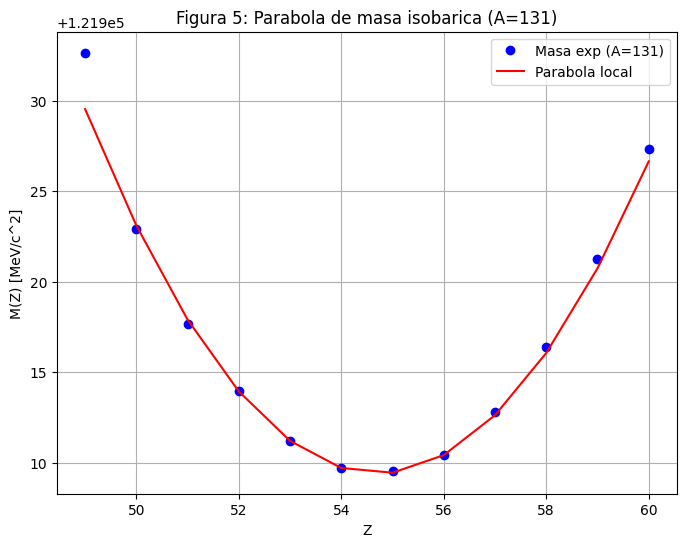

In [6]:
def M_parabola(Z):
    """Masa nuclear predicha por la parabola local ajustada, en MeV/c^2."""
    return alpha_loc + beta_loc * Z + gamma_loc * Z**2


Z_all = df_A131["Z"].values
M_exp_all = df_A131["mass"].values

Z_min, Z_max = Z_all.min(), Z_all.max()
Z_rango = np.arange(Z_min, Z_max + 1)
M_teorica = M_parabola(Z_rango)

plt.figure(figsize=(8, 6))
plt.plot(Z_all, M_exp_all, "bo", label="Masa exp (A=131)")
plt.plot(Z_rango, M_teorica, "r-", label="Parabola local")
plt.xlabel("Z")
plt.ylabel("M(Z) [MeV/c^2]")
plt.title("Figura 5: Parabola de masa isobarica (A=131)")
plt.legend()
plt.grid(True)
plt.show()

**Figura 5**: los puntos azules corresponden a la masa experimental para cada $Z$ con $A=131$, y la curva roja al ajuste parabólico local. La curva ajustada describe razonablemente la variación de la masa con $Z$ para los isóbaros de $A = 131$.

---

## 5. Cálculo de $Q_\beta$ y Comparación con Datos

El valor $Q_\beta$ para la transición $(Z, A) \to (Z+1, A)$ se define como

$$
Q_\beta = M(Z,A) - M(Z+1,A).
$$

Se calculan tanto la versión teórica, con la parábola ajustada, como la experimental, con las masas obtenidas directamente de los datos, para todos los isóbaros de $A = 131$ disponibles.

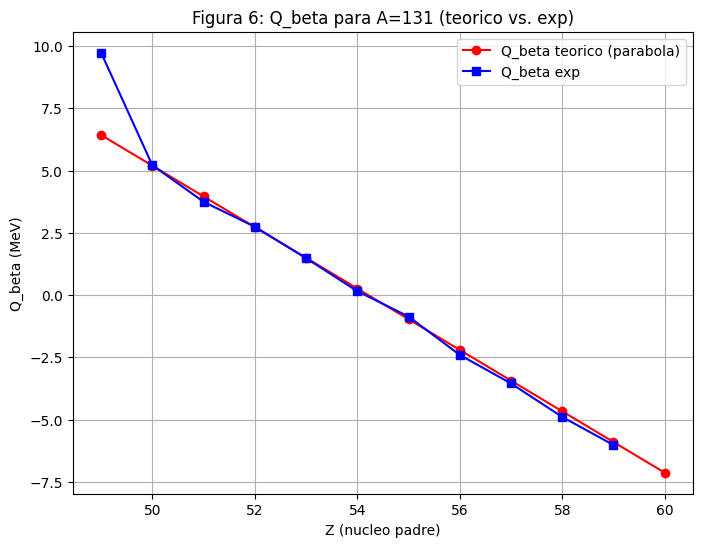

Comparacion numerica Q_beta (teo vs exp) para A=131:
Z=49: Q_teo=6.428 MeV, Q_exp=9.733 MeV
Z=50: Q_teo=5.195 MeV, Q_exp=5.215 MeV
Z=51: Q_teo=3.962 MeV, Q_exp=3.746 MeV
Z=52: Q_teo=2.729 MeV, Q_exp=2.743 MeV
Z=53: Q_teo=1.496 MeV, Q_exp=1.482 MeV
Z=54: Q_teo=0.263 MeV, Q_exp=0.156 MeV
Z=55: Q_teo=-0.970 MeV, Q_exp=-0.864 MeV
Z=56: Q_teo=-2.203 MeV, Q_exp=-2.404 MeV
Z=57: Q_teo=-3.436 MeV, Q_exp=-3.551 MeV
Z=58: Q_teo=-4.669 MeV, Q_exp=-4.896 MeV
Z=59: Q_teo=-5.902 MeV, Q_exp=-6.021 MeV
Z=60: Q_teo=-7.135 MeV, sin datos exp


In [7]:
def Qbeta_teorico(Z):
    """Q_beta teorico (MeV) para la transicion (Z, A=131) -> (Z+1, A=131).

    Se calcula como la diferencia de masas predichas por la parabola local:
    Q_beta(Z) = M_parabola(Z) - M_parabola(Z+1).
    """
    return M_parabola(Z) - M_parabola(Z + 1)


# Serie indexada por Z para obtener la masa experimental de cualquier
# isobaro de A=131 sin necesidad de filtrar el DataFrame en un bucle.
masa_por_Z = df_A131.set_index("Z")["mass"].sort_index()
Z_sorted = masa_por_Z.index.values

Q_teo = Qbeta_teorico(Z_sorted)

# Q_beta experimental: diferencia entre la masa de Z y la de Z+1. Cuando
# Z+1 no esta en la tabla, reindex produce NaN y ese punto se descarta.
masa_siguiente = masa_por_Z.reindex(Z_sorted + 1).values
Q_exp = masa_por_Z.values - masa_siguiente
hay_dato_exp = ~np.isnan(Q_exp)

plt.figure(figsize=(8, 6))
plt.plot(Z_sorted, Q_teo, "ro-", label="Q_beta teorico (parabola)")
plt.plot(Z_sorted[hay_dato_exp], Q_exp[hay_dato_exp], "bs-", label="Q_beta exp")
plt.xlabel("Z (nucleo padre)")
plt.ylabel("Q_beta (MeV)")
plt.title("Figura 6: Q_beta para A=131 (teorico vs. exp)")
plt.legend()
plt.grid(True)
plt.show()

print("Comparacion numerica Q_beta (teo vs exp) para A=131:")
for z, qt, qe, tiene_exp in zip(Z_sorted, Q_teo, Q_exp, hay_dato_exp):
    if tiene_exp:
        print(f"Z={z}: Q_teo={qt:.3f} MeV, Q_exp={qe:.3f} MeV")
    else:
        print(f"Z={z}: Q_teo={qt:.3f} MeV, sin datos exp")

**Figura 6**: se muestra la comparación entre los valores de $Q_\beta$ teóricos (línea roja) y experimentales (línea azul). La tabla numérica indica que, en general, los valores del ajuste se acercan bastante a los experimentales, con diferencias que reflejan la aproximación del modelo parabólico local.

---

## 6. Núcleo Más Estable para A = 131

Para la parábola $M(Z) = \alpha + \beta Z + \gamma Z^2$, la condición de estabilidad local (mínimo de la masa) se obtiene cuando

$$
\frac{dM}{dZ} = 0 \quad \Rightarrow \quad \beta + 2\,\gamma\,Z = 0 \quad \Rightarrow \quad
Z_\mathrm{i} = -\frac{\beta}{2\,\gamma}.
$$

In [8]:
Z_i = -beta_loc / (2 * gamma_loc)
print(f"Z_i (mas estable) segun la parabola local = {Z_i:.3f}")

Z_i (mas estable) segun la parabola local = 54.713


Este valor no suele ser un entero; sin embargo, indica alrededor de qué $Z$ (isótopo) se obtiene la mayor estabilidad, es decir, la menor masa, para $A = 131$.

---

## 7. Predicción de $Q_\beta$ para $^{131}\mathrm{Sb} \to {}^{131}\mathrm{Te}$ y $^{131}\mathrm{La} \to {}^{131}\mathrm{Ce}$

Se calculan específicamente:

- $Q_\beta(^{131}\mathrm{Sb} \to {}^{131}\mathrm{Te})$, con $Z = 51 \to 52$.
- $Q_\beta(^{131}\mathrm{La} \to {}^{131}\mathrm{Ce})$, con $Z = 57 \to 58$.

Los resultados se comparan con los valores experimentales disponibles.

In [9]:
def Qbeta_experimental(Z):
    """Q_beta experimental (MeV) para (Z, A=131) -> (Z+1, A=131).

    Devuelve None si alguna de las dos masas no esta disponible en la
    tabla de datos.
    """
    if Z in masa_por_Z.index and (Z + 1) in masa_por_Z.index:
        return masa_por_Z.loc[Z] - masa_por_Z.loc[Z + 1]
    return None


Z_Sb, Z_La = 51, 57

Q_Sb_teo = Qbeta_teorico(Z_Sb)
Q_La_teo = Qbeta_teorico(Z_La)
print(f"Prediccion Q_beta(131Sb->131Te) (teorico) = {Q_Sb_teo:.3f} MeV")
print(f"Prediccion Q_beta(131La->131Ce) (teorico) = {Q_La_teo:.3f} MeV")

Q_Sb_exp = Qbeta_experimental(Z_Sb)
Q_La_exp = Qbeta_experimental(Z_La)

print(f"Q_beta(131Sb->131Te) exp = {Q_Sb_exp:.3f} MeV" if Q_Sb_exp is not None
      else "No hay datos experimentales para 131Sb->131Te")
print(f"Q_beta(131La->131Ce) exp = {Q_La_exp:.3f} MeV" if Q_La_exp is not None
      else "No hay datos experimentales para 131La->131Ce")

Prediccion Q_beta(131Sb->131Te) (teorico) = 3.962 MeV
Prediccion Q_beta(131La->131Ce) (teorico) = -3.436 MeV
Q_beta(131Sb->131Te) exp = 3.746 MeV
Q_beta(131La->131Ce) exp = -3.551 MeV


---

## 8. Ajuste Directo de $Q_\beta$ Experimental y Búsqueda de $Z_p$

En esta sección se realiza un ajuste de mínimos cuadrados (polinomio de grado 2) a los valores experimentales de $Q_\beta$ para $A = 131$, y se determina el valor $Z_p$ que satisface

$$
Q_\beta(Z) = M_{\exp}(Z) - M_{\exp}(Z+1) = 0.
$$

Este valor de $Z_p$ se compara con $Z_i$, obtenido previamente a partir de la derivada de la parábola de masa.

In [10]:
# Se reutilizan los arreglos Z_sorted y Q_exp calculados en la Seccion 5,
# restringidos a los puntos con dato experimental disponible.
Z_ajuste = Z_sorted[hay_dato_exp].astype(float)
Q_ajuste = Q_exp[hay_dato_exp]

# Ajuste polinomico de grado 2 a Q_beta experimental.
coef = np.polyfit(Z_ajuste, Q_ajuste, deg=2)  # [a2, a1, a0]
a2, a1, a0 = coef
print(f"Coeficientes: a2={a2:.5f}, a1={a1:.5f}, a0={a0:.5f}")

# Raiz del polinomio dentro del rango de Z observado.
raices = np.roots(coef)
raices_reales = raices[np.isreal(raices)].real
candidatas = [z for z in raices_reales if Z_ajuste.min() <= z <= Z_ajuste.max()]

if candidatas:
    Z_p = candidatas[0]
    print(f"Z_p = {Z_p:.3f} (donde Q_beta(Z)=0)")
else:
    Z_p = None
    print("No se encontro raiz real en el rango de Z.")

Coeficientes: a2=0.05622, a1=-7.46900, a0=239.32394
Z_p = 53.945 (donde Q_beta(Z)=0)


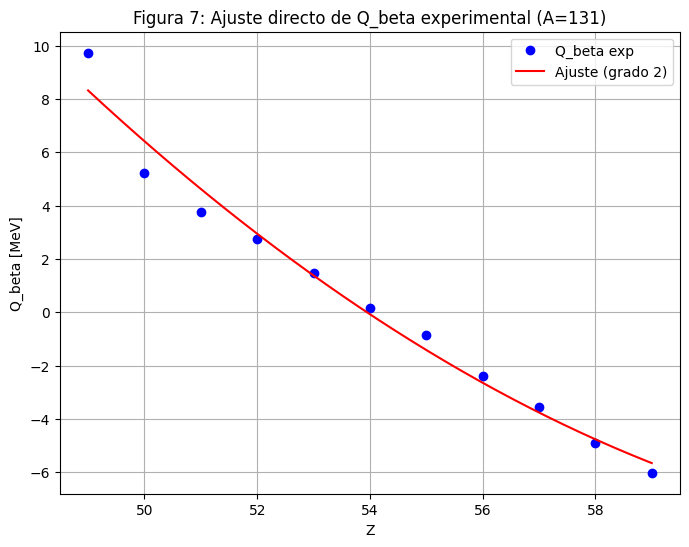

In [11]:
Z_fit_range = np.linspace(Z_ajuste.min(), Z_ajuste.max(), 200)
Q_fit_curve = a2 * Z_fit_range**2 + a1 * Z_fit_range + a0

plt.figure(figsize=(8, 6))
plt.plot(Z_ajuste, Q_ajuste, "bo", label="Q_beta exp")
plt.plot(Z_fit_range, Q_fit_curve, "r-", label="Ajuste (grado 2)")
plt.xlabel("Z")
plt.ylabel("Q_beta [MeV]")
plt.title("Figura 7: Ajuste directo de Q_beta experimental (A=131)")
plt.legend()
plt.grid(True)
plt.show()

**Figura 7**: los puntos azules representan los datos experimentales de $Q_\beta$, y la línea roja corresponde al ajuste polinómico de grado 2 obtenido a partir de dichos datos.

In [12]:
print("Comparacion:")
print(f"Z_i (masa parabolica) = {Z_i:.3f}")
print(f"Z_p (ajuste Q_beta)   = {Z_p:.3f}")
print(f"Diferencia: |Z_p - Z_i| = {abs(Z_p - Z_i):.3f}")

Comparacion:
Z_i (masa parabolica) = 54.713
Z_p (ajuste Q_beta)   = 53.945
Diferencia: |Z_p - Z_i| = 0.768


### 8.1. Análisis Adicional de los Resultados

**Discrepancias fuera del rango de ajuste local.** Al examinar la Figura 6, la mayor discrepancia entre la curva teórica y la experimental se presenta en $Z = 49$. Esto se debe a que el ajuste parabólico se realizó únicamente con los datos de $Z = 52$, $54$ y $56$, lo que limita la precisión del modelo al extrapolar a valores de $Z$ alejados de ese rango. Ampliar el conjunto de puntos usados en el ajuste, o emplear un método de mínimos cuadrados con un mayor número de núcleos isobáricos, permitiría obtener una curva local válida en un rango más amplio de $Z$.

**Efecto del término de apareamiento ($\delta$).** La fórmula de gota líquida utilizada no incorpora el término de apareamiento, que introduce correcciones relevantes para núcleos con número par o impar de protones y neutrones. Incluir este término podría mejorar el ajuste, en particular en la estimación de la masa nuclear y en la determinación de $Q_\beta$ para núcleos con $Z$ o $N$ impares.

**Interpretación de $Q_\beta$ negativo.** Los valores negativos de $Q_\beta$, por ejemplo para $Z \geq 55$, indican que la desintegración $\beta^-$ no es energéticamente favorable en esos casos. Esto sugiere que el núcleo podría estabilizarse mediante otros modos de decaimiento, como la desintegración $\beta^+$ o la captura electrónica, o que la desintegración efectiva ocurra hacia un estado excitado que no se contempla en este modelo simplificado.

---

## 9. Conclusiones

1. **Modelo de gota líquida (global).** Reproduce la tendencia general de la energía de enlace por nucleón y permite descomponer los aportes de volumen, superficie, Coulomb y asimetría. Las diferencias con los datos experimentales se deben a la omisión de efectos de apareamiento, deformaciones nucleares y otros fenómenos de estructura fina.

2. **Ajuste local para A = 131.** La aproximación parabólica obtenida a partir de los datos de $^{131}\mathrm{Te}$, $^{131}\mathrm{Xe}$ y $^{131}\mathrm{Ba}$ describe adecuadamente la variación de la masa nuclear con el número de protones. Los valores de $Q_\beta$ calculados con este ajuste son cercanos a los valores experimentales, lo que respalda el uso de la aproximación local para isóbaros.

3. **Ajuste directo de $Q_\beta$ experimental.** El ajuste de un polinomio de grado 2 a los valores experimentales de $Q_\beta$, que permite hallar el punto $Z_p$ donde $Q_\beta = 0$, ofrece una estimación independiente del punto de estabilidad. La cercanía entre $Z_p$ y $Z_i$ (obtenido a partir de la derivada de la parábola de masa) confirma que ambos métodos señalan la misma región de estabilidad para $A = 131$.

4. **Predicción específica de $Q_\beta$.** Para la transición $^{131}\mathrm{Sb} \to {}^{131}\mathrm{Te}$, la predicción teórica es de aproximadamente $3.96$ MeV, frente a un valor experimental de $\approx 3.75$ MeV. Para $^{131}\mathrm{La} \to {}^{131}\mathrm{Ce}$, la predicción es de aproximadamente $-3.44$ MeV, consistente con el valor experimental de $\approx -3.55$ MeV; el signo negativo indica que esta transición, en la forma planteada, no es energéticamente favorable, lo que sugiere la posibilidad de otro modo de decaimiento (por ejemplo, $\beta^+$ o captura electrónica).

5. **Recomendaciones y perspectivas futuras.** Incluir el término de apareamiento y posibles correcciones de deformación nuclear podría mejorar la precisión del modelo, especialmente al analizar diferencias de masa de unas pocas centésimas de MeV. Ampliar el número de núcleos isobáricos usados en el ajuste local permitiría obtener una curva más robusta y representativa en un rango extendido de $Z$.

En conjunto, los resultados obtenidos muestran la utilidad de las aproximaciones semiempíricas y locales para el estudio de masas nucleares y energías de decaimiento, y ofrecen una base para futuras extensiones del análisis.

---

## Referencias

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., … Oliphant, T. E. (2020). Array programming with NumPy. *Nature*, *585*(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, *9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

Krane, K. S. (1988). *Introductory nuclear physics*. John Wiley & Sons.

Wang, M., Huang, W. J., Kondev, F. G., Audi, G., & Naimi, S. (2021). The AME 2020 atomic mass evaluation (II). Tables, graphs and references. *Chinese Physics C*, *45*(3), 030003. https://doi.org/10.1088/1674-1137/abddaf

*Nota:* el archivo de datos `mybinding.dat` sigue el formato característico de las evaluaciones de masas atómicas (Wang et al., 2021), pero no fue posible confirmar con certeza la edición específica de la que proviene.